# Federated Learning Results Visualization

- Global performance plots: AUROC, F1, precision, recall
- Validation loss trend
- Communication cost plots
- Runtime/compute-time plots
- Per-client training loss plots
- Per-client compute-time plots



## 1. Import libraries

We use `pandas` for loading/cleaning data and `matplotlib` for plotting.

In [31]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Set file paths



In [30]:
base_dir = Path('/s/chopin/a/grad/C837864364/Projects/Federated-Thoracic-Pathology-Classification/fl_logs/master')

fl_metrics_path = base_dir / "fl_metrics.json"
master_metrics_path = base_dir / "master_metrics_final.json"


## 3. Load JSON data

Each JSON file contains a list of dictionaries. Each dictionary represents one training round.

In [4]:
# Load one main result file
# You can switch this to master_metrics_path if needed.
metrics_path = fl_metrics_path

with open(metrics_path, "r") as f:
    metrics = json.load(f)

print("Number of rounds:", len(metrics))
print("Keys in one round:")
print(metrics[0].keys())

Number of rounds: 28
Keys in one round:
dict_keys(['round_num', 'wall_time_s', 'aggregation_time_s', 'max_client_compute_s', 'total_upload_mb', 'total_download_mb', 'auroc_macro', 'f1_macro', 'recall_macro', 'precision_macro', 'val_loss', 'mia_vulnerability', 'bandwidth_efficiency', 'client_stats'])


## Create two DataFrames

In [ ]:
full_df = pd.DataFrame(metrics)
global_df = full_df.drop(columns=["client_stats"], errors="ignore")

client_rows = []
for round_record in metrics:
    round_num = round_record["round_num"]
    for client_record in round_record.get("client_stats", []):
        row = client_record.copy()
        row["round_num"] = round_num
        client_rows.append(row)

client_df = pd.DataFrame(client_rows)

# Convert bytes to MB for easier plotting
if not client_df.empty:
    client_df["upload_mb"] = client_df["upload_bytes"] / (1024 * 1024)
    client_df["download_mb"] = client_df["download_bytes"] / (1024 * 1024)
    client_df["client_id"] = client_df["client_id"].astype(str)

global_df.head()


,round_num,wall_time_s,aggregation_time_s,max_client_compute_s,total_upload_mb,total_download_mb,auroc_macro,f1_macro,recall_macro,precision_macro,val_loss,mia_vulnerability,bandwidth_efficiency
0,1,44.203058,0.0,74.842682,90.861504,90.861504,0.611941,0.164925,0.172601,0.197921,0.129476,NaN,0.003367
1,2,51.839729,0.0,73.353137,90.861504,90.861504,0.649153,0.145717,0.142808,0.212646,0.125512,NaN,0.000205
2,3,43.997302,0.0,70.362675,90.861504,90.861504,0.681999,0.172677,0.164030,0.274112,0.123793,NaN,0.000181
3,4,46.469292,0.0,168.957332,90.861504,90.861504,0.695810,0.199059,0.189594,0.281617,0.122431,NaN,0.000076
4,5,53.520199,0.0,217.104929,90.861504,90.861504,0.711835,0.218715,0.216441,0.275350,0.120064,NaN,0.000088


In [8]:
client_df.head()

,client_id,round_num,compute_time_s,upload_bytes,download_bytes,train_loss,num_examples,upload_mb,download_mb
0,413162.0,1,74.842682,30287168,30287168,0.157202,3649,28.884094,28.884094
1,655056.0,1,59.546260,30287168,30287168,0.171474,5401,28.884094,28.884094
2,557090.0,1,67.553363,30287168,30287168,0.146167,3509,28.884094,28.884094
3,557090.0,2,65.802597,30287168,30287168,0.112773,3509,28.884094,28.884094
4,413162.0,2,73.353137,30287168,30287168,0.126445,3649,28.884094,28.884094


In [11]:
client_df.tail()

,client_id,round_num,compute_time_s,upload_bytes,download_bytes,train_loss,num_examples,upload_mb,download_mb
79,413162.0,27,127.389354,30287168,30287168,0.070582,3649,28.884094,28.884094
80,655056.0,27,153.417551,30287168,30287168,0.065574,5401,28.884094,28.884094
81,655056.0,28,152.264638,30287168,30287168,0.062460,5401,28.884094,28.884094
82,413162.0,28,124.129156,30287168,30287168,0.069008,3649,28.884094,28.884094
83,557090.0,28,81.841785,30287168,30287168,0.061827,3509,28.884094,28.884094


## 5. Quick summary

In [10]:
print("Global metrics shape:", global_df.shape)
print("Client metrics shape:", client_df.shape)
print("Clients:", sorted(client_df["client_id"].unique()) if not client_df.empty else [])


Global metrics shape: (28, 13)
Client metrics shape: (84, 9)
Clients: ['413162.0', '557090.0', '655056.0']


## global model performance


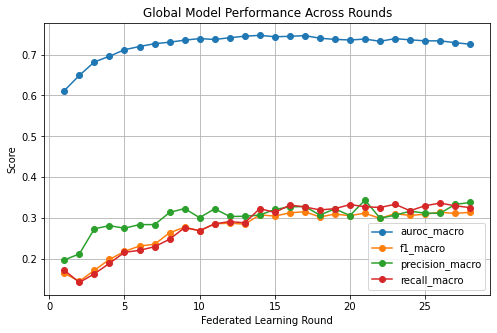

In [12]:
performance_cols = ["auroc_macro", "f1_macro", "precision_macro", "recall_macro"]

for col in performance_cols:
    if col in global_df.columns:
        plt.plot(global_df["round_num"], global_df[col], marker="o", label=col)

plt.xlabel("Federated Learning Round")
plt.ylabel("Score")
plt.title("Global Model Performance Across Rounds")
plt.legend()
plt.show()

## Plot validation loss


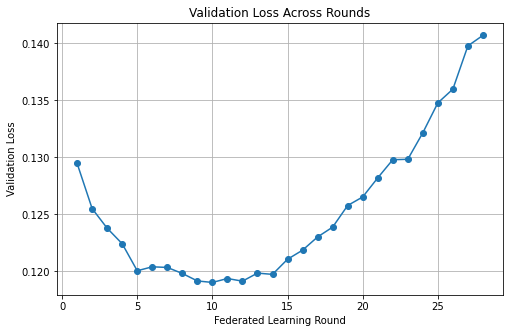

In [13]:
if "val_loss" in global_df.columns:
    plt.plot(global_df["round_num"], global_df["val_loss"], marker="o")
    plt.xlabel("Federated Learning Round")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Across Rounds")
    plt.show()

## AUROC and validation loss together

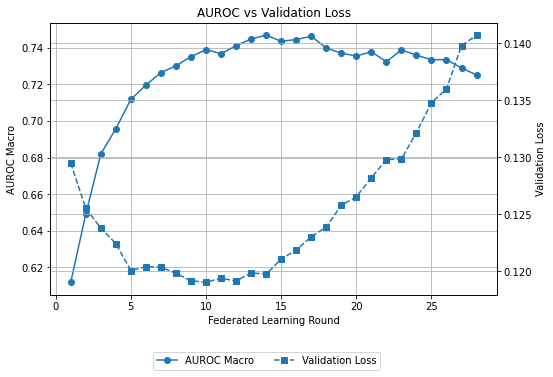

In [29]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(global_df["round_num"], global_df["auroc_macro"], marker="o", label="AUROC Macro")
ax1.set_xlabel("Federated Learning Round")
ax1.set_ylabel("AUROC Macro")

ax2 = ax1.twinx()
ax2.plot(global_df["round_num"], global_df["val_loss"], marker="s", linestyle="--", label="Validation Loss")
ax2.set_ylabel("Validation Loss")

plt.title("AUROC vs Validation Loss")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.show()

## Plot communication cost

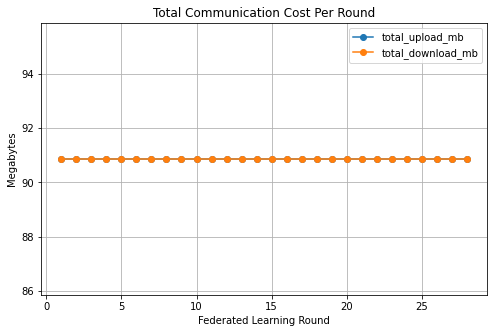

In [28]:
comm_cols = ["total_upload_mb", "total_download_mb"]

for col in comm_cols:
    if col in global_df.columns:
        plt.plot(global_df["round_num"], global_df[col], marker="o", label=col)

plt.xlabel("Federated Learning Round")
plt.ylabel("Megabytes")
plt.title("Total Communication Cost Per Round")
plt.legend()
plt.show()

## Plot runtime and client compute time



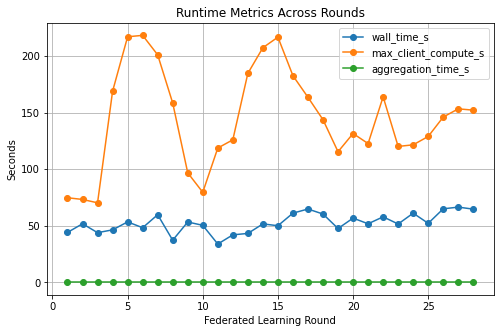

In [27]:
runtime_cols = ["wall_time_s", "max_client_compute_s", "aggregation_time_s"]

for col in runtime_cols:
    if col in global_df.columns:
        plt.plot(global_df["round_num"], global_df[col], marker="o", label=col)

plt.xlabel("Federated Learning Round")
plt.ylabel("Seconds")
plt.title("Runtime Metrics Across Rounds")
plt.legend()
plt.show()

## per-client training loss


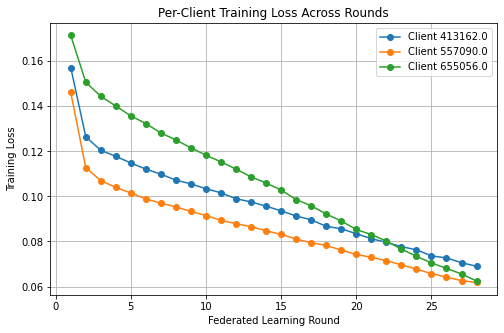

In [26]:
if not client_df.empty and "train_loss" in client_df.columns:
    for client_id, group in client_df.groupby("client_id"):
        group = group.sort_values("round_num")
        plt.plot(group["round_num"], group["train_loss"], marker="o", label=f"Client {client_id}")

    plt.xlabel("Federated Learning Round")
    plt.ylabel("Training Loss")
    plt.title("Per-Client Training Loss Across Rounds")
    plt.legend()
    plt.show()

# per-client compute time

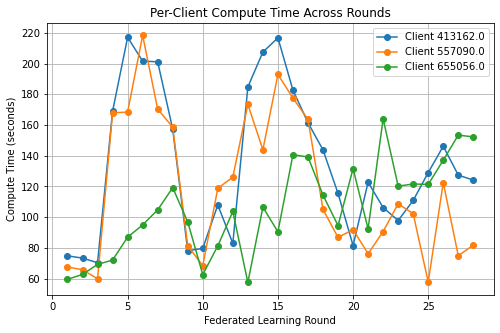

In [25]:
if not client_df.empty and "compute_time_s" in client_df.columns:
    for client_id, group in client_df.groupby("client_id"):
        group = group.sort_values("round_num")
        plt.plot(group["round_num"], group["compute_time_s"], marker="o", label=f"Client {client_id}")

    plt.xlabel("Federated Learning Round")
    plt.ylabel("Compute Time (seconds)")
    plt.title("Per-Client Compute Time Across Rounds")
    plt.legend()
    plt.show()

## Average client training loss per round

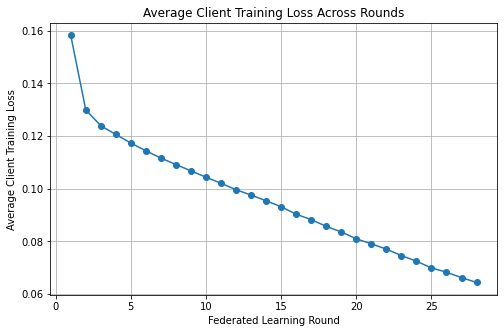

,round_num,train_loss
0,1,0.158281
1,2,0.129954
2,3,0.123973
3,4,0.120628
4,5,0.117362
5,6,0.114445
6,7,0.111661
7,8,0.109212
8,9,0.106808
9,10,0.104405


In [24]:
if not client_df.empty and "train_loss" in client_df.columns:
    avg_train_loss = client_df.groupby("round_num", as_index=False)["train_loss"].mean()

    plt.plot(avg_train_loss["round_num"], avg_train_loss["train_loss"], marker="o")
    plt.xlabel("Federated Learning Round")
    plt.ylabel("Average Client Training Loss")
    plt.title("Average Client Training Loss Across Rounds")
    plt.show()

    display(avg_train_loss)

## number of examples per client

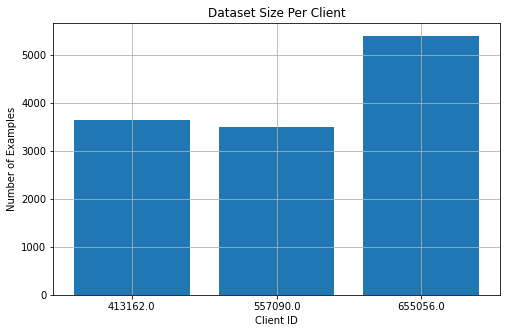

,client_id,num_examples
0,413162.0,3649
1,557090.0,3509
2,655056.0,5401


In [23]:
if not client_df.empty and "num_examples" in client_df.columns:
    examples_per_client = client_df.groupby("client_id", as_index=False)["num_examples"].max()

    plt.bar(examples_per_client["client_id"], examples_per_client["num_examples"])
    plt.xlabel("Client ID")
    plt.ylabel("Number of Examples")
    plt.title("Dataset Size Per Client")
    plt.show()

    display(examples_per_client)

In [22]:
# def load_global_metrics(path):
#     with open(path, "r") as f:
#         data = json.load(f)
#     df = pd.DataFrame(data).drop(columns=["client_stats"], errors="ignore")
#     df["source_file"] = path.name
#     return df

# if fl_metrics_path.exists() and master_metrics_path.exists():
#     compare_df = pd.concat([
#         load_global_metrics(fl_metrics_path),
#         load_global_metrics(master_metrics_path)
#     ], ignore_index=True)

#     display(compare_df.head())

#     for source_file, group in compare_df.groupby("source_file"):
#         plt.plot(group["round_num"], group["auroc_macro"], marker="o", label=source_file)

#     plt.xlabel("Federated Learning Round")
#     plt.ylabel("AUROC Macro")
#     plt.title("AUROC Comparison Across JSON Files")
#     plt.legend()
#     plt.show()

checklist

We can use these points when writing your project report:

- Did AUROC increase over rounds?
- Did F1 score increase over rounds?
- Did validation loss decrease over rounds?
- Which client had the highest training loss?
- Which client had the highest compute time?
- Was communication cost constant or changing?
- Is there client data imbalance based on `num_examples`?